In [53]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score ,f1_score
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

In [54]:
# Load the dataset
data = load_breast_cancer()

In [55]:
# Convert to DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [56]:
# Select ONE feature and target
X = df[['mean radius']]   # one feature
y = data.target           # 0 = malignant, 1 = benign

In [57]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [58]:
# Scale the feature
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data preparation complete.")

Data preparation complete.


In [59]:
# Train SVM model
model = SVC(kernel='linear')
model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [60]:
# Evaluate model
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
print(f"Training accuracy: {train_score:.2f}")
print(f"Test accuracy: {test_score:.2f}")

Training accuracy: 0.88
Test accuracy: 0.93


In [61]:
# Predictions
y_pred = model.predict(X_test)


Confusion Matrix:
[[36  7]
 [ 1 70]]


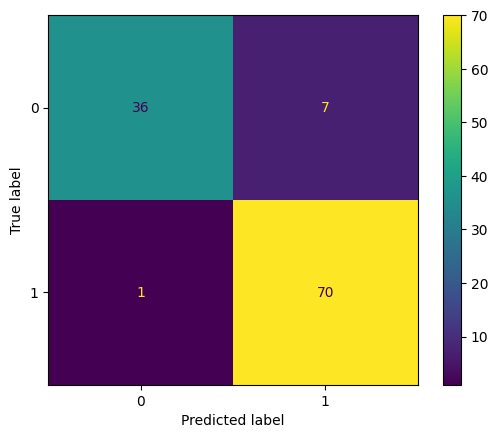

In [62]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

The confusion matrix shows that the model correctly classifies most cases, but some malignant tumors are incorrectly predicted, which may affect reliability in medical diagnosis.

In [68]:
## Classification 
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.84      0.90        43
           1       0.91      0.99      0.95        71

    accuracy                           0.93       114
   macro avg       0.94      0.91      0.92       114
weighted avg       0.93      0.93      0.93       114



In [67]:
## Evaluation
print("Precision Score -->",precision_score(y_test, y_pred))
print("Recall Score -->",recall_score(y_test, y_pred))
print("F1 Score -->",f1_score(y_test,y_pred))

Precision Score --> 0.9090909090909091
Recall Score --> 0.9859154929577465
F1 Score --> 0.9459459459459459


Data preparation complete.
Training accuracy: 0.89
Test accuracy: 0.90

Confusion Matrix:
[[36  7]
 [ 4 67]]


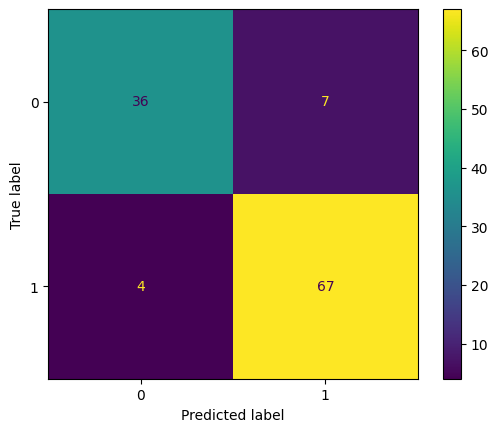

              precision    recall  f1-score   support

           0       0.90      0.84      0.87        43
           1       0.91      0.94      0.92        71

    accuracy                           0.90       114
   macro avg       0.90      0.89      0.90       114
weighted avg       0.90      0.90      0.90       114



In [4]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score ,f1_score
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Load the dataset
data = load_breast_cancer()

# Convert to DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df.head()

# Select ONE feature and target
# X = df[['mean radius']]   # one feature
X = df[['mean radius', 'mean texture']]
y = data.target           # 0 = malignant, 1 = benign

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale the feature
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data preparation complete.")

# Train SVM model
model = SVC(kernel='linear')
model.fit(X_train, y_train)

# Evaluate model
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
print(f"Training accuracy: {train_score:.2f}")
print(f"Test accuracy: {test_score:.2f}")

# Predictions
y_pred = model.predict(X_test)
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

## Classification 
print(classification_report(y_test, y_pred))

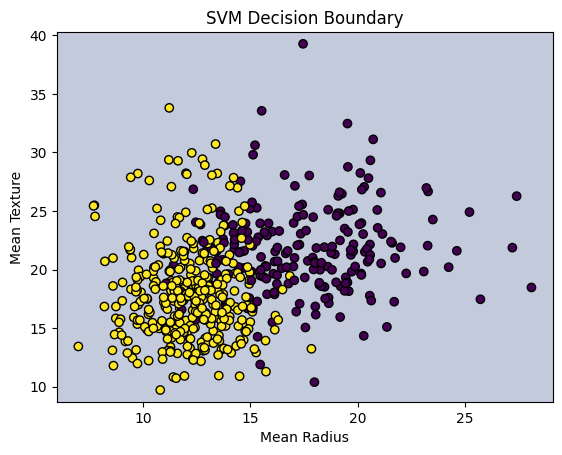

In [5]:
import numpy as np

# Create mesh grid
x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

# Predict on grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot data points
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, edgecolors='k')

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("SVM Decision Boundary")
plt.show()

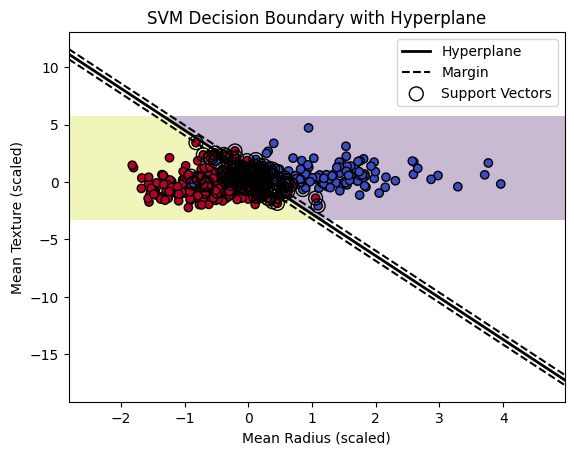

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Load dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

# Select TWO features
X = df[['mean radius', 'mean texture']]
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVM (linear kernel)
model = SVC(kernel='linear')
model.fit(X_train_scaled, y_train)

# -----------------------------
# Visualization
# -----------------------------

# Create mesh grid
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Predict on grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot background regions
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot data points
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1],
            c=y_train, cmap='coolwarm', edgecolors='k')

# -----------------------------
# Hyperplane + Margins
# -----------------------------

# Get weights and bias
w = model.coef_[0]
b = model.intercept_[0]

# Create line for hyperplane
x_points = np.linspace(x_min, x_max, 100)
y_points = -(w[0] * x_points + b) / w[1]

# Plot hyperplane
plt.plot(x_points, y_points, 'k-', linewidth=2, label='Hyperplane')

# Plot margins
margin = 1 / np.sqrt(np.sum(w**2))

y_margin_up = y_points + margin
y_margin_down = y_points - margin

plt.plot(x_points, y_margin_up, 'k--', label='Margin')
plt.plot(x_points, y_margin_down, 'k--')

# -----------------------------
# Support Vectors
# -----------------------------

plt.scatter(model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=100, facecolors='none', edgecolors='black',
            label='Support Vectors')

# Labels and title
plt.xlabel("Mean Radius (scaled)")
plt.ylabel("Mean Texture (scaled)")
plt.title("SVM Decision Boundary with Hyperplane")
plt.legend()

plt.show()